## Notebook 5 of 5: Evaluating the trained classifiers

1. [`01_overview_and_vep.ipynb`](./01_overview_and_vep.ipynb) -- setup, family-aware
   train/test split, gene/ontology descriptions, AlphaGenome reference-only overview plots,
   classical Variant Effect Prediction (VEP).
2. [`02_individual_predictions.ipynb`](./02_individual_predictions.ipynb) -- per-individual
   consensus RNA-seq, comparing two individuals, bulk prediction generation.
3. [`03_population_analysis.ipynb`](./03_population_analysis.ipynb) -- population-level
   comparison, MANE-exon restriction, single-ontology restriction, significance test.
4. [`04_modeling.ipynb`](./04_modeling.ipynb) -- trains a LogisticRegression classifier on
   MANE-exon-restricted features, a second on whole-gene-span features, and a tiny torch MLP
   on the full concatenated signal; persists all three to `notebooks/.cache/models/`.
5. [`05_evaluation.ipynb`](./05_evaluation.ipynb) -- loads the persisted models, evaluates them
   on the held-out test split, reference/variant label prediction, literature-vs-background
   variant comparison.

**This is notebook 5.** It loads `mane_exon_model`, `gene_span_model`, `nn_model`, `nn_scaler`,
and the held-out test features notebook 4 persisted to `notebooks/.cache/models/` -- no model
fitting or `notebooks/.cache/predictions/` reads happen here. The reference-genome/variant
prediction and literature-vs-background comparison sections at the end make fresh AlphaGenome
API calls, so `ALPHAGENOME_API_KEY` is still needed to run this notebook end to end.


In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

REPO_ROOT = Path("/home/breno/I2CA/genomics")
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
os.chdir(NOTEBOOK_DIR)

from utils import setup, rna_features
from utils import predictions as predictions_utils
from utils import models as models_utils
from alphagenome.data import genome
from alphagenome.models import dna_client

ctx = setup.load_experiment(NOTEBOOK_DIR)
GENES, ONTOLOGY_TERMS, CLASS_MAP = ctx.GENES, ctx.ONTOLOGY_TERMS, ctx.CLASS_MAP
gene_rows, individuals, samples_by_class = ctx.gene_rows, ctx.individuals, ctx.samples_by_class
windows_df, gtf = ctx.windows_df, ctx.gtf
PREDICTIONS_CACHE_DIR = ctx.PREDICTIONS_CACHE_DIR
REFERENCE_PREDICTIONS_CACHE_DIR = ctx.REFERENCE_PREDICTIONS_CACHE_DIR

train_samples_by_class, test_samples_by_class = setup.get_train_test_split(individuals, CLASS_MAP)

# Only the reference-genome/variant prediction section further down makes fresh AlphaGenome API
# calls (predict_reference_interval is cached per gene, predict_variant_effect is not) -- the
# evaluation sections above it only read notebooks/.cache/models/ (built by notebook 4).
client, ORGANISM = setup.create_client()
print("AlphaGenome client ready.")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MODELS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "models"
metadata = models_utils.load_metadata(MODELS_CACHE_DIR / "model_metadata.json")
assert metadata["GENES"] == GENES, "notebook 4's GENES order must match this notebook's"
significant_genes = metadata["significant_genes"]
gene_widths = metadata["gene_widths"]
gene_offsets = metadata["gene_offsets"]
feature_dim = metadata["feature_dim"]
MODEL_ONTOLOGY_TERMS = metadata["MODEL_ONTOLOGY_TERMS"]

gene_zoom_slices = rna_features.compute_gene_zoom_slices(gtf, GENES, dna_client.SEQUENCE_LENGTH_500KB)

mane_exon_model = models_utils.load_sklearn_model(MODELS_CACHE_DIR / "mane_exon_model.joblib")
gene_span_model = models_utils.load_sklearn_model(MODELS_CACHE_DIR / "gene_span_model.joblib")
nn_scaler = models_utils.load_sklearn_model(MODELS_CACHE_DIR / "nn_scaler.joblib")
nn_model = models_utils.load_nn_model(
    MODELS_CACHE_DIR / "nn_model_state_dict.pt",
    input_dim=feature_dim,
    hidden_dim=metadata["nn_hidden_dim"],
    device=device,
)
print("Loaded mane_exon_model, gene_span_model, nn_model, nn_scaler from", MODELS_CACHE_DIR)

test_features_df = pd.read_csv(MODELS_CACHE_DIR / "test_features_mane_exon.csv")
test_gene_features_df = pd.read_csv(MODELS_CACHE_DIR / "test_features_gene_span.csv")
_nn_test = np.load(MODELS_CACHE_DIR / "test_features_nn.npz")
X_test_nn, y_test_nn, nn_test_ids = _nn_test["X"], _nn_test["y"], _nn_test["sample_ids"]

X_test = test_features_df[significant_genes].values
y_test = (test_features_df["label"] == "strong pigmentation").to_numpy(dtype=int)
X_test_gene = test_gene_features_df[significant_genes].values
y_test_gene = (test_gene_features_df["label"] == "strong pigmentation").to_numpy(dtype=int)

print(f"Test-split sizes: mane-exon {X_test.shape}, gene-span {X_test_gene.shape}, NN {X_test_nn.shape}")


/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AlphaGenome client ready.
Using device: cuda
Loaded mane_exon_model, gene_span_model, nn_model, nn_scaler from /home/breno/I2CA/genomics/notebooks/.cache/models
Test-split sizes: mane-exon (210, 10), gene-span (210, 10), NN (210, 952122)


## Evaluating `mane_exon_model` (LogisticRegression, MANE-exon log-means)

Held-out accuracy/ROC-AUC/confusion matrix/classification report for the classifier notebook 4
fit on MANE-exon-restricted, log-transformed per-gene means -- the same `X_test`/`y_test` split
notebook 4 built and persisted, so these numbers reproduce exactly what notebook 4 would have
printed inline, without needing its kernel state.


In [2]:
y_pred = mane_exon_model.predict(X_test)
y_proba = mane_exon_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion matrix (rows=true, cols=pred; 0=weak, 1=strong):")
print(confusion_matrix(y_test, y_pred))
print("\n" + classification_report(y_test, y_pred, target_names=["weak pigmentation", "strong pigmentation"]))

coef_df = pd.DataFrame({
    "gene": significant_genes,
    "coefficient": mane_exon_model.named_steps["logisticregression"].coef_[0],
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)
coef_df


Accuracy: 0.810
ROC-AUC : 0.899

Confusion matrix (rows=true, cols=pred; 0=weak, 1=strong):
[[ 58  19]
 [ 21 112]]

                     precision    recall  f1-score   support

  weak pigmentation       0.73      0.75      0.74        77
strong pigmentation       0.85      0.84      0.85       133

           accuracy                           0.81       210
          macro avg       0.79      0.80      0.80       210
       weighted avg       0.81      0.81      0.81       210



,gene,coefficient
0,MC1R,1.078643
1,TYR,-1.054742
2,MFSD12,-0.981834
3,TYRP1,-0.942715
4,SLC45A2,-0.511306
5,SLC24A5,0.210386
6,HERC2,0.208155
7,DDB1,-0.196829
8,TCHH,-0.147824
9,EDAR,-0.049820


## Evaluating `gene_span_model` (LogisticRegression, whole-gene log-means)

Same evaluation, for the follow-up classifier fit on whole-gene-span (not just MANE-exon) means.


In [3]:
y_pred_gene = gene_span_model.predict(X_test_gene)
y_proba_gene = gene_span_model.predict_proba(X_test_gene)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_gene, y_pred_gene):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test_gene, y_proba_gene):.3f}")
print("\nConfusion matrix (rows=true, cols=pred; 0=weak, 1=strong):")
print(confusion_matrix(y_test_gene, y_pred_gene))
print("\n" + classification_report(y_test_gene, y_pred_gene, target_names=["weak pigmentation", "strong pigmentation"]))

gene_span_coef_df = pd.DataFrame({
    "gene": significant_genes,
    "coefficient": gene_span_model.named_steps["logisticregression"].coef_[0],
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)
gene_span_coef_df


Accuracy: 0.886
ROC-AUC : 0.956

Confusion matrix (rows=true, cols=pred; 0=weak, 1=strong):
[[ 62  15]
 [  9 124]]

                     precision    recall  f1-score   support

  weak pigmentation       0.87      0.81      0.84        77
strong pigmentation       0.89      0.93      0.91       133

           accuracy                           0.89       210
          macro avg       0.88      0.87      0.87       210
       weighted avg       0.89      0.89      0.88       210



,gene,coefficient
0,MFSD12,-2.193303
1,MC1R,1.322696
2,TYR,-0.944620
3,TYRP1,-0.863769
4,SLC24A5,0.598147
5,SLC45A2,-0.562299
6,DDB1,-0.190904
7,HERC2,0.183843
8,TCHH,-0.149077
9,EDAR,-0.106633


## Evaluating `nn_model` (tiny MLP, full concatenated signal)

Same evaluation, for the tiny MLP fit on the full ~950k-dimensional concatenated per-position
signal across all 11 genes. Recall the heavy-overfitting caveat from notebook 4: this is a
`p >> n` regime (~860 train individuals vs. ~950k features), so treat these held-out numbers as
a rough sanity check, not a tuned result.


In [4]:
y_test_nn_int = y_test_nn.astype(int)
X_test_t = torch.from_numpy(X_test_nn).to(device)

nn_model.eval()
with torch.no_grad():
    test_proba = torch.sigmoid(nn_model(X_test_t)).cpu().numpy()
test_pred = (test_proba > 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_test_nn_int, test_pred):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test_nn_int, test_proba):.3f}")
print("\nConfusion matrix (rows=true, cols=pred; 0=weak, 1=strong):")
print(confusion_matrix(y_test_nn_int, test_pred))
print("\n" + classification_report(y_test_nn_int, test_pred, target_names=["weak pigmentation", "strong pigmentation"]))


Accuracy: 0.995
ROC-AUC : 1.000

Confusion matrix (rows=true, cols=pred; 0=weak, 1=strong):
[[ 77   0]
 [  1 132]]

                     precision    recall  f1-score   support

  weak pigmentation       0.99      1.00      0.99        77
strong pigmentation       1.00      0.99      1.00       133

           accuracy                           1.00       210
          macro avg       0.99      1.00      0.99       210
       weighted avg       1.00      1.00      1.00       210



## Predicting a label for the reference genome, and for a single variant

Using `nn_model` (loaded above, trained on the full concatenated gene-span signal), this
predicts a pigmentation label for two synthetic "individuals":

1. **The unmodified reference genome.** There's no H1/H2 consensus here -- just AlphaGenome's
   `predict_interval` on the raw reference sequence for each gene (`predict_reference_interval`,
   the same cached helper notebook 1's overview plots use, requested here with the same
   `MODEL_ONTOLOGY_TERMS` used to train the model above). Every trained feature was an **H1+H2
   sum**, so to put the reference genome on the same scale, its single-haplotype signal is
   **doubled** -- i.e. treated as a hypothetical individual who is homozygous reference at every
   gene. This is a modeling approximation, not a measurement: real diploid genomes vary, this
   just gives the model something on a comparable scale.
2. **The reference genome with one variant applied**, using `predict_variant_effect` (the same
   REF/ALT prediction notebook 1's "Classical Variant Effect Prediction" section uses) for a
   single gene/variant -- everything else stays at the doubled reference signal, and only that one
   gene's slot in the concatenated feature vector is replaced with the (doubled) ALT-allele
   prediction. This isolates the effect of exactly one SNP on the model's predicted class.

Take both predictions with real skepticism: the model was trained on ~860 real individuals with a
~950k-dimensional input (see the heavy-overfitting caveat above), and both of these inputs are
synthetic, out-of-distribution constructions (no real genome is "homozygous reference at every
variant"), not draws from that same distribution -- this is more a demonstration of the
pipeline/API than a validated biological prediction.


In [5]:
VARIANT_ONTOLOGY_TERMS = MODEL_ONTOLOGY_TERMS  # keep this consistent with the models above


def reference_gene_span_signal(gene: str) -> np.ndarray:
    """Reference-genome analog of individual_gene_span_signal: AlphaGenome's prediction on the
    unmodified reference sequence, strand-filtered, restricted to MODEL_ONTOLOGY_TERMS, cropped
    to the gene's own GTF span, then doubled to approximate a homozygous-reference individual
    (every trained feature was an H1+H2 *sum*, so a single reference haplotype alone would sit
    at half that scale)."""
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    interval = genome.Interval(gene_data["chrom"], gene_data["start"], gene_data["end"])
    strand = rna_features.gene_strand(gtf, gene)
    lo, hi = gene_zoom_slices[gene]

    track = predictions_utils.predict_reference_interval(
        client,
        gene=gene,
        interval=interval,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=VARIANT_ONTOLOGY_TERMS,
        cache_dir=REFERENCE_PREDICTIONS_CACHE_DIR,
    )
    track = track.filter_to_positive_strand() if strand == "+" else track.filter_to_negative_strand()
    return 2 * track.values.sum(axis=1)[lo:hi].astype(np.float32)


def build_reference_feature_vector(override_gene: str = None, override_signal: np.ndarray = None) -> np.ndarray:
    """Concatenates every gene's (doubled) reference-genome signal, in the same GENES order /
    offsets used to build X_train_nn/X_test_nn -- optionally swapping in a precomputed signal
    (e.g. a doubled ALT-allele prediction) for one gene."""
    x = np.empty(feature_dim, dtype=np.float32)
    for gene in GENES:
        offset, width = gene_offsets[gene], gene_widths[gene]
        x[offset:offset + width] = (
            override_signal if gene == override_gene else reference_gene_span_signal(gene)
        )
    return x


def predict_label(x: np.ndarray) -> tuple:
    x_scaled = nn_scaler.transform(x.reshape(1, -1)).astype(np.float32)
    nn_model.eval()
    with torch.no_grad():
        proba = torch.sigmoid(nn_model(torch.from_numpy(x_scaled).to(device))).item()
    return ("strong pigmentation" if proba > 0.5 else "weak pigmentation"), proba


from utils import literature_variants

VARIANT_GENE = "MFSD12"
# Programmatically fetched (GTEx skin-tissue eQTLs), not hand-curated -- see notebook 1's VEP
# section and notebooks/utils/literature_variants.py. Same cache as notebook 1, so this is a
# cache hit if notebook 1 already ran.
MFSD12_LITERATURE_VARIANTS = literature_variants.literature_variant_strings(
    VARIANT_GENE, windows_df, ctx.ANNOTATIONS_CACHE_DIR, top_n=literature_variants.DEFAULT_TOP_N,
)
print(f"Fetched {len(MFSD12_LITERATURE_VARIANTS)} GTEx skin-eQTL literature variant(s) for {VARIANT_GENE}.")

mfsd12_window = windows_df.loc[windows_df["gene"] == VARIANT_GENE].iloc[0]
mfsd12_interval = genome.Interval(mfsd12_window["chrom"], mfsd12_window["start"], mfsd12_window["end"])
mfsd12_strand_04 = rna_features.gene_strand(gtf, VARIANT_GENE)
mfsd12_lo, mfsd12_hi = gene_zoom_slices[VARIANT_GENE]

mfsd12_alt_signal_cache: dict = {}  # variant string -> doubled full-window ALT signal, reused below


def mfsd12_alt_signal(variant_str: str) -> np.ndarray:
    """Fetches (and caches in-session, keyed by variant string) MFSD12's doubled full-window
    ALT signal for one variant -- one fresh predict_variant_effect API call per distinct
    variant. Reused below both for the multi-variant label predictions and for the rain-plot
    comparison further down, so each literature variant is only ever scored once."""
    if variant_str not in mfsd12_alt_signal_cache:
        _, alt_track = predictions_utils.predict_variant_effect(
            client,
            gene=VARIANT_GENE,
            interval=mfsd12_interval,
            variant=genome.Variant.from_str(variant_str),
            requested_outputs=[dna_client.OutputType.RNA_SEQ],
            ontology_terms=VARIANT_ONTOLOGY_TERMS,
        )
        alt_track = alt_track.filter_to_positive_strand() if mfsd12_strand_04 == "+" else alt_track.filter_to_negative_strand()
        mfsd12_alt_signal_cache[variant_str] = 2 * alt_track.values.sum(axis=1).astype(np.float32)
    return mfsd12_alt_signal_cache[variant_str]


# --- 1. Unmodified reference genome ---
x_ref = build_reference_feature_vector()
ref_label, ref_proba = predict_label(x_ref)
print(f"Reference genome -> predicted label: {ref_label} (P[strong pigmentation]={ref_proba:.3f})")

# --- 2. Reference genome + each of MFSD12's GTEx-eQTL literature variants (notebook 1's VEP section) ---
variant_prediction_rows = []
for variant_str in MFSD12_LITERATURE_VARIANTS:
    full_signal = mfsd12_alt_signal(variant_str)
    x_variant = build_reference_feature_vector(
        override_gene=VARIANT_GENE, override_signal=full_signal[mfsd12_lo:mfsd12_hi]
    )
    variant_label, variant_proba = predict_label(x_variant)
    variant_prediction_rows.append({
        "variant": variant_str,
        "predicted_label": variant_label,
        "P[strong pigmentation]": variant_proba,
        "shift_from_reference": variant_proba - ref_proba,
    })
    print(f"{VARIANT_GENE} {variant_str} -> {variant_label} (P[strong pigmentation]={variant_proba:.3f}, "
          f"shift {variant_proba - ref_proba:+.3f})")

variant_predictions_df = pd.DataFrame(variant_prediction_rows)
variant_predictions_df


Fetched 10 GTEx skin-eQTL literature variant(s) for MFSD12.
Reference genome -> predicted label: weak pigmentation (P[strong pigmentation]=0.000)
MFSD12 chr19:3565255:G>A -> weak pigmentation (P[strong pigmentation]=0.000, shift +0.000)
MFSD12 chr19:3565911:T>C -> weak pigmentation (P[strong pigmentation]=0.000, shift +0.000)
MFSD12 chr19:3566515:T>C -> weak pigmentation (P[strong pigmentation]=0.000, shift +0.000)
MFSD12 chr19:3565601:T>C -> weak pigmentation (P[strong pigmentation]=0.000, shift +0.000)
MFSD12 chr19:3566633:C>T -> weak pigmentation (P[strong pigmentation]=0.000, shift +0.000)
MFSD12 chr19:3565359:C>T -> weak pigmentation (P[strong pigmentation]=0.000, shift +0.000)
MFSD12 chr19:3565912:G>C -> weak pigmentation (P[strong pigmentation]=0.000, shift +0.000)
MFSD12 chr19:3565094:T>G -> weak pigmentation (P[strong pigmentation]=0.000, shift +0.000)
MFSD12 chr19:3578775:C>T -> weak pigmentation (P[strong pigmentation]=0.000, shift +0.000)
MFSD12 chr19:3575424:T>C -> weak pi

,variant,predicted_label,P[strong pigmentation],shift_from_reference
0,chr19:3565255:G>A,weak pigmentation,0.0,0.0
1,chr19:3565911:T>C,weak pigmentation,0.0,0.0
2,chr19:3566515:T>C,weak pigmentation,0.0,0.0
3,chr19:3565601:T>C,weak pigmentation,0.0,0.0
4,chr19:3566633:C>T,weak pigmentation,0.0,0.0
5,chr19:3565359:C>T,weak pigmentation,0.0,0.0
6,chr19:3565912:G>C,weak pigmentation,0.0,0.0
7,chr19:3565094:T>G,weak pigmentation,0.0,0.0
8,chr19:3578775:C>T,weak pigmentation,0.0,0.0
9,chr19:3575424:T>C,weak pigmentation,0.0,0.0


## Comparing literature vs. background MFSD12 variants: `score_variants` vs. this notebook's 3 classifiers

Notebook 1 compared MFSD12's curated literature variants against real 1000 Genomes background
SNVs using AlphaGenome's `score_variants` (a `GeneMaskLFCScorer` RNA-seq log2 fold-change,
restricted to melanocyte-of-skin) in a rain+density plot. This section first recreates that exact
plot here -- same background set (same VCF, allele-frequency threshold, and random seed, via
`data_utils.sample_background_variants_from_vcf`, the helper notebook 1's background-sampling cell
was refactored to import from `notebooks/utils/data.py` so both notebooks draw from one
implementation and compare against the identical background variants) -- then builds an analogous
plot using each of this notebook's 3 trained classifiers instead of `score_variants`:

- `mane_exon_model` -- LogisticRegression on MANE-exon-restricted log-means.
- `gene_span_model` -- LogisticRegression on whole-gene-span log-means.
- `nn_model` -- the tiny MLP on the full concatenated per-position signal.

For each variant, every gene *except MFSD12* is held at its (doubled) reference-genome baseline --
the same "hypothetical homozygous-reference individual" approximation the section above uses -- and
MFSD12's slot alone is replaced by that variant's predicted signal, isolating each classifier's
response to exactly one SNP (the same idea `raw_score` uses to isolate one SNP's effect on
RNA-seq). Instead of a probability, this reads off each model's raw **logit** (log-odds before
sigmoid: `decision_function` for the two LogisticRegression pipelines, the pre-sigmoid output for
the tiny MLP) -- a signed, unbounded score, more directly comparable to `score_variants`'
`raw_score` (also signed and unbounded) than a bounded probability would be.

The 7 literature variants' ALT signal is reused from the `mfsd12_alt_signal` cache built above (no
repeat API calls); only the 30 background variants need fresh `predict_variant_effect` calls here.


In [6]:
from utils import data as data_utils

_, mfsd12_vcf_path = data_utils.gene_paths("MFSD12")
mfsd12_literature_positions = {genome.Variant.from_str(v).position for v in MFSD12_LITERATURE_VARIANTS}
mfsd12_background_variants = data_utils.sample_background_variants_from_vcf(
    mfsd12_vcf_path,
    exclude_positions=mfsd12_literature_positions,
    min_allele_frequency=0.01,
    n=30,
)
print(f"Sampled {len(mfsd12_background_variants)} background SNV(s) -- same VCF/threshold/seed as notebook 1.")


def mfsd12_variant_str(v) -> str:
    return f"{v.chromosome}:{v.position}:{v.reference_bases}>{v.alternate_bases}"


from alphagenome.models import variant_scorers

rna_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS["RNA_SEQ"]
mfsd12_literature_variant_objs = [genome.Variant.from_str(v) for v in MFSD12_LITERATURE_VARIANTS]


def score_variants_rna(variants_list: list, gene: str) -> pd.DataFrame:
    """RNA_SEQ score_variants for a batch of variants, tidied and restricted to `gene`'s
    melanocyte-of-skin track -- generalized (originally MFSD12-only) so the concordance
    section further down can reuse it for every gene."""
    intervals = [v.reference_interval.resize(dna_client.SEQUENCE_LENGTH_500KB) for v in variants_list]
    raw = client.score_variants(
        intervals=intervals, variants=variants_list, variant_scorers=[rna_scorer], max_workers=2
    )
    tidy = variant_scorers.tidy_scores(raw, match_gene_strand=True)
    return tidy[(tidy["gene_name"] == gene) & (tidy["ontology_curie"] == ONTOLOGY_TERMS[0])].copy()


literature_score_slice = score_variants_rna(mfsd12_literature_variant_objs, "MFSD12")
literature_score_slice["is_literature_variant"] = True
background_score_slice = score_variants_rna(mfsd12_background_variants, "MFSD12")
background_score_slice["is_literature_variant"] = False

score_comparison_df = pd.concat([literature_score_slice, background_score_slice], ignore_index=True)
score_comparison_df["position"] = score_comparison_df["variant_id"].map(lambda v: v.position)
score_comparison_df


Sampled 30 background SNV(s) -- same VCF/threshold/seed as notebook 1.


100%|██████████| 30/30 [00:17<00:00,  1.68it/s]


,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,...,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,raw_score,quantile_score,is_literature_variant,position
0,chr19:3565255:G>A,chr19:3303111-3827399:.,ENSG00000161091,MFSD12,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,primary_cell,adult,,encode,paired,False,-0.016722,-0.999087,True,3565255
1,chr19:3565911:T>C,chr19:3303767-3828055:.,ENSG00000161091,MFSD12,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,primary_cell,adult,,encode,paired,False,-0.000990,-0.706871,True,3565911
2,chr19:3566515:T>C,chr19:3304371-3828659:.,ENSG00000161091,MFSD12,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,primary_cell,adult,,encode,paired,False,-0.002466,-0.912385,True,3566515
3,chr19:3565601:T>C,chr19:3303457-3827745:.,ENSG00000161091,MFSD12,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,primary_cell,adult,,encode,paired,False,-0.000422,-0.494571,True,3565601
4,chr19:3566633:C>T,chr19:3304489-3828777:.,ENSG00000161091,MFSD12,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,primary_cell,adult,,encode,paired,False,0.000159,0.341464,True,3566633
5,chr19:3565359:C>T,chr19:3303215-3827503:.,ENSG00000161091,MFSD12,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,primary_cell,adult,,encode,paired,False,0.000942,0.698293,True,3565359
6,chr19:3565912:G>C,chr19:3303768-3828056:.,ENSG00000161091,MFSD12,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,primary_cell,adult,,encode,paired,False,-0.000152,-0.326413,True,3565912
7,chr19:3565094:T>G,chr19:3302950-3827238:.,ENSG00000161091,MFSD12,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,primary_cell,adult,,encode,paired,False,-0.001180,-0.746766,True,3565094
8,chr19:3578775:C>T,chr19:3316631-3840919:.,ENSG00000161091,MFSD12,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,primary_cell,adult,,encode,paired,False,-0.000786,-0.642441,True,3578775
9,chr19:3575424:T>C,chr19:3313280-3837568:.,ENSG00000161091,MFSD12,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,primary_cell,adult,,encode,paired,False,-0.000197,-0.356342,True,3575424


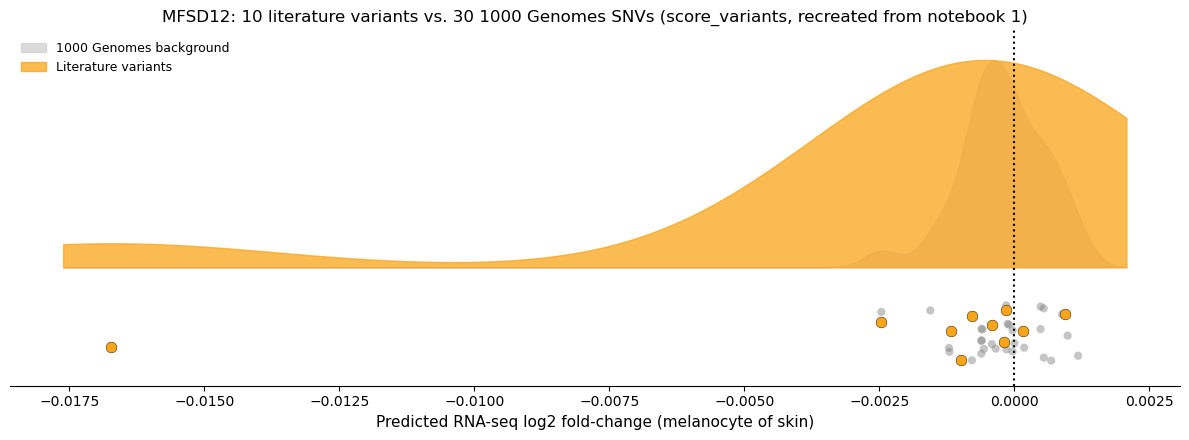

In [7]:
from scipy.stats import gaussian_kde


def rain_density_plot(ax, background_values: np.ndarray, literature_values: np.ndarray, title: str, xlabel: str) -> None:
    """Same rain+density style as notebook 1's background-comparison plot: a KDE ridge on top
    (skipped for a group if it has <2 distinct values -- gaussian_kde needs nonzero variance)
    plus a jittered strip of individual points below."""
    xmin = min(background_values.min(), literature_values.min())
    xmax = max(background_values.max(), literature_values.max())
    pad = (xmax - xmin) * 0.05 if xmax > xmin else 1.0
    x = np.linspace(xmin - pad, xmax + pad, 500)

    height = 0.35
    if len(np.unique(background_values)) >= 2:
        y_bg = gaussian_kde(background_values, bw_method=0.4)(x)
        ax.fill_between(x, 0, y_bg / y_bg.max() * height, color="lightgray", alpha=0.8, label="1000 Genomes background")
    if len(np.unique(literature_values)) >= 2:
        y_lit = gaussian_kde(literature_values, bw_method=0.6)(x)
        ax.fill_between(x, 0, y_lit / y_lit.max() * height, color="#FAA41A", alpha=0.75, label="Literature variants")

    rng = np.random.default_rng(42)
    bg_y = -0.06 - rng.random(len(background_values)) * 0.10
    lit_y = -0.06 - rng.random(len(literature_values)) * 0.10
    ax.scatter(background_values, bg_y, s=35, color="gray", alpha=0.45, edgecolor="none")
    ax.scatter(literature_values, lit_y, s=60, color="#FAA41A", edgecolor="black", linewidth=0.3, zorder=5)

    ax.axvline(0, color="black", linestyle=":", linewidth=1.5)
    ax.set_ylim(-0.20, height + 0.05)
    ax.set_yticks([])
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(frameon=False, fontsize=9)
    for spine in ("left", "right", "top"):
        ax.spines[spine].set_visible(False)


fig, ax = plt.subplots(figsize=(12, 4.5))
rain_density_plot(
    ax,
    score_comparison_df.loc[~score_comparison_df["is_literature_variant"], "raw_score"].to_numpy(),
    score_comparison_df.loc[score_comparison_df["is_literature_variant"], "raw_score"].to_numpy(),
    title=(
        f"MFSD12: {len(literature_score_slice)} literature variants vs. "
        f"{len(background_score_slice)} 1000 Genomes SNVs (score_variants, recreated from notebook 1)"
    ),
    xlabel="Predicted RNA-seq log2 fold-change (melanocyte of skin)",
)
plt.tight_layout()
plt.show()


In [8]:
def reference_gene_scalar_features(gene: str) -> dict:
    """Reference-genome (doubled) MANE-exon and whole-gene-span log-means for one gene -- the
    baseline the two LogisticRegression models use for every gene except MFSD12 below."""
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    interval = genome.Interval(gene_data["chrom"], gene_data["start"], gene_data["end"])
    strand = rna_features.gene_strand(gtf, gene)
    window_size = gene_data["end"] - gene_data["start"]
    lo, hi = gene_zoom_slices[gene]
    mask = rna_features.mane_exon_mask(gtf, gene, gene_data["start"], window_size)

    track = predictions_utils.predict_reference_interval(
        client,
        gene=gene,
        interval=interval,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=VARIANT_ONTOLOGY_TERMS,
        cache_dir=REFERENCE_PREDICTIONS_CACHE_DIR,
    )
    track = track.filter_to_positive_strand() if strand == "+" else track.filter_to_negative_strand()
    full_signal = 2 * track.values.sum(axis=1).astype(np.float32)
    return {
        "mane_exon_log_mean": np.log(full_signal[mask].mean() + 0.001),
        "gene_span_log_mean": np.log(full_signal[lo:hi].mean() + 0.001),
    }


reference_scalar_by_gene = {gene: reference_gene_scalar_features(gene) for gene in significant_genes}

mfsd12_window_size = mfsd12_window["end"] - mfsd12_window["start"]
mfsd12_mask = rna_features.mane_exon_mask(gtf, VARIANT_GENE, mfsd12_window["start"], mfsd12_window_size)


def model_logits_for_variant(variant_str: str) -> dict:
    """One MFSD12 ALT signal (reused via mfsd12_alt_signal's cache) reused three ways: a
    MANE-exon log-mean for mane_exon_model, a whole-gene-span log-mean for gene_span_model, and
    the raw per-position span for nn_model -- every other gene stays at its reference baseline."""
    full_signal = mfsd12_alt_signal(variant_str)
    mane_exon_log_mean = np.log(full_signal[mfsd12_mask].mean() + 0.001)
    gene_span_log_mean = np.log(full_signal[mfsd12_lo:mfsd12_hi].mean() + 0.001)

    mane_exon_row = np.array([[
        mane_exon_log_mean if gene == VARIANT_GENE else reference_scalar_by_gene[gene]["mane_exon_log_mean"]
        for gene in significant_genes
    ]])
    gene_span_row = np.array([[
        gene_span_log_mean if gene == VARIANT_GENE else reference_scalar_by_gene[gene]["gene_span_log_mean"]
        for gene in significant_genes
    ]])

    x_nn = build_reference_feature_vector(override_gene=VARIANT_GENE, override_signal=full_signal[mfsd12_lo:mfsd12_hi])
    x_nn_scaled = nn_scaler.transform(x_nn.reshape(1, -1)).astype(np.float32)
    nn_model.eval()
    with torch.no_grad():
        nn_logit = nn_model(torch.from_numpy(x_nn_scaled).to(device)).item()

    return {
        "mane_exon_logit": mane_exon_model.decision_function(mane_exon_row)[0],
        "gene_span_logit": gene_span_model.decision_function(gene_span_row)[0],
        "nn_logit": nn_logit,
    }


t0 = time.time()
logit_rows = []
for variant_str in MFSD12_LITERATURE_VARIANTS:
    logit_rows.append({"variant": variant_str, "is_literature_variant": True, **model_logits_for_variant(variant_str)})
for v in mfsd12_background_variants:
    variant_str = mfsd12_variant_str(v)
    logit_rows.append({"variant": variant_str, "is_literature_variant": False, **model_logits_for_variant(variant_str)})
print(f"Computed 3-model logits for {len(logit_rows)} variants in {time.time() - t0:.1f}s")

logit_comparison_df = pd.DataFrame(logit_rows)
logit_comparison_df


Computed 3-model logits for 40 variants in 347.0s


,variant,is_literature_variant,mane_exon_logit,gene_span_logit,nn_logit
0,chr19:3565255:G>A,True,-2.491795,-2.705569,-216.049240
1,chr19:3565911:T>C,True,-2.963102,-3.840040,-297.750214
2,chr19:3566515:T>C,True,-2.990840,-3.910762,-299.921509
3,chr19:3565601:T>C,True,-2.986842,-3.910147,-298.333374
4,chr19:3566633:C>T,True,-3.014130,-3.944173,-298.122284
5,chr19:3565359:C>T,True,-2.971361,-3.832630,-289.708130
6,chr19:3565912:G>C,True,-2.981698,-3.878253,-301.944275
7,chr19:3565094:T>G,True,-2.942178,-3.808487,-292.606384
8,chr19:3578775:C>T,True,-2.987300,-3.889628,-299.703369
9,chr19:3575424:T>C,True,-2.996088,-3.908093,-296.926117


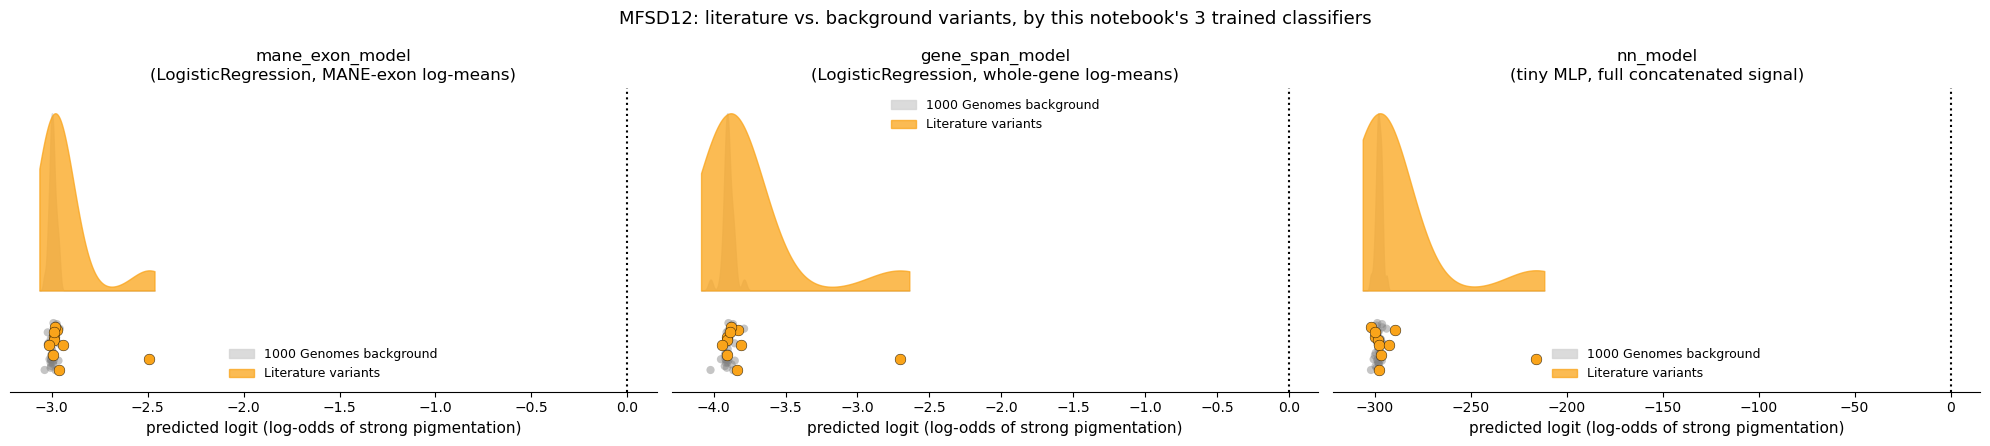

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
model_specs = [
    ("mane_exon_logit", "mane_exon_model\n(LogisticRegression, MANE-exon log-means)"),
    ("gene_span_logit", "gene_span_model\n(LogisticRegression, whole-gene log-means)"),
    ("nn_logit", "nn_model\n(tiny MLP, full concatenated signal)"),
]
for ax, (col, title) in zip(axes, model_specs):
    rain_density_plot(
        ax,
        logit_comparison_df.loc[~logit_comparison_df["is_literature_variant"], col].to_numpy(),
        logit_comparison_df.loc[logit_comparison_df["is_literature_variant"], col].to_numpy(),
        title=title,
        xlabel="predicted logit (log-odds of strong pigmentation)",
    )
fig.suptitle("MFSD12: literature vs. background variants, by this notebook's 3 trained classifiers", fontsize=13)
plt.tight_layout()
plt.show()


## Does AlphaGenome's predicted direction agree with GTEx's known direction? (all genes)

Every section above used AlphaGenome's own predictions as ground truth. This section instead
checks the pipeline against an **independent** measurement: for every gene, GTEx skin-tissue
eQTLs give each literature variant a signed, real-world direction of effect on expression
(`known_direction`, `nes` sign -- see notebook 1's VEP section and
`notebooks/utils/literature_variants.py`). AlphaGenome's `score_variants` independently predicts
its own signed direction (`predicted_direction`, `raw_score` sign, melanocyte-of-skin RNA-seq).

`agree = (predicted_direction == known_direction)` per variant is a genuine concordance check
between the pipeline's predictions and known biology -- not just a demonstration that the
pipeline runs. Genes with zero significant skin eQTLs in GTEx (confirmed for
`SLC45A2`/`DDB1`/`EDAR`/`HERC2`/`TCHH` at the time this was written) are skipped, not silently
dropped -- reported explicitly below.


In [10]:
TOP_N_LITERATURE_VARIANTS_PER_GENE = 10

literature_by_gene = literature_variants.get_literature_variants_all_genes(
    GENES, windows_df, ctx.ANNOTATIONS_CACHE_DIR, top_n=TOP_N_LITERATURE_VARIANTS_PER_GENE,
)
for gene in GENES:
    n = len(literature_by_gene[gene])
    print(f"{gene}: {n} GTEx skin-eQTL literature variant(s)" + (" -- skipping below" if n == 0 else ""))


MC1R: 10 GTEx skin-eQTL literature variant(s)
TYRP1: 10 GTEx skin-eQTL literature variant(s)
TYR: 10 GTEx skin-eQTL literature variant(s)
SLC45A2: 0 GTEx skin-eQTL literature variant(s) -- skipping below
DDB1: 0 GTEx skin-eQTL literature variant(s) -- skipping below
EDAR: 0 GTEx skin-eQTL literature variant(s) -- skipping below
MFSD12: 10 GTEx skin-eQTL literature variant(s)
OCA2: 10 GTEx skin-eQTL literature variant(s)
HERC2: 0 GTEx skin-eQTL literature variant(s) -- skipping below
SLC24A5: 2 GTEx skin-eQTL literature variant(s)
TCHH: 0 GTEx skin-eQTL literature variant(s) -- skipping below


In [11]:
concordance_rows = []
for gene in GENES:
    lit_df = literature_by_gene[gene]
    if lit_df.empty:
        continue

    variant_objs = [genome.Variant.from_str(v) for v in lit_df["variant"]]
    scored = score_variants_rna(variant_objs, gene)
    raw_score_by_variant = {
        f"{v.chromosome}:{v.position}:{v.reference_bases}>{v.alternate_bases}": raw_score
        for v, raw_score in zip(scored["variant_id"], scored["raw_score"])
    }

    for _, lit_row in lit_df.iterrows():
        raw_score = raw_score_by_variant.get(lit_row["variant"])
        if raw_score is None:
            continue  # variant's own 500kb window didn't retain a gene_name match after tidy_scores
        predicted_direction = "enhance" if raw_score > 0 else "diminish"
        concordance_rows.append({
            "gene": gene,
            "variant": lit_row["variant"],
            "known_direction": lit_row["direction"],
            "nes": lit_row["nes"],
            "p_value": lit_row["p_value"],
            "raw_score": raw_score,
            "predicted_direction": predicted_direction,
            "agree": predicted_direction == lit_row["direction"],
        })

concordance_df = pd.DataFrame(concordance_rows)
print(f"Scored {len(concordance_df)} literature variant(s) across "
      f"{concordance_df['gene'].nunique()} gene(s) with GTEx skin eQTLs.")
concordance_df


100%|██████████| 2/2 [00:00<00:00,  3.24it/s]

Scored 52 literature variant(s) across 6 gene(s) with GTEx skin eQTLs.


,gene,variant,known_direction,nes,p_value,raw_score,predicted_direction,agree
0,MC1R,chr16:89913750:A>G,enhance,0.396056,1.605271e-27,-0.001297,diminish,False
1,MC1R,chr16:89909088:G>A,enhance,0.395801,1.716044e-27,0.001387,enhance,True
2,MC1R,chr16:89909147:G>C,enhance,0.395801,1.716044e-27,0.003838,enhance,True
3,MC1R,chr16:89909164:A>G,enhance,0.395801,1.716044e-27,0.000789,enhance,True
4,MC1R,chr16:89906663:G>A,enhance,0.394049,4.232801e-27,0.000690,enhance,True
5,MC1R,chr16:89911930:G>A,enhance,0.404799,6.091766e-27,0.000304,enhance,True
6,MC1R,chr16:89913443:C>A,enhance,0.390668,1.478430e-26,-0.001669,diminish,False
7,MC1R,chr16:89906008:C>A,enhance,0.390600,1.953550e-26,-0.001749,diminish,False
8,MC1R,chr16:89908325:C>T,enhance,0.391346,4.064243e-26,0.000008,enhance,True
9,MC1R,chr16:89908321:CCCA>C,enhance,0.387075,1.306815e-25,0.005172,enhance,True


In [12]:
overall_rate = concordance_df["agree"].mean()
print(f"Overall concordance (AlphaGenome predicted direction == GTEx known direction): "
      f"{overall_rate:.1%} ({concordance_df['agree'].sum()}/{len(concordance_df)})")
if abs(overall_rate - 0.5) < 0.05:
    print("WARNING: concordance is near chance (50%) -- check for a sign-convention bug "
          "before treating this as a weak biological result.")

per_gene_summary = (
    concordance_df.groupby("gene")["agree"]
    .agg(n_variants="count", concordant="sum")
    .assign(concordance_rate=lambda d: d["concordant"] / d["n_variants"])
    .reindex(GENES)
)
per_gene_summary


Overall concordance (AlphaGenome predicted direction == GTEx known direction): 57.7% (30/52)


,n_variants,concordant,concordance_rate
gene,,,
MC1R,10.0,7.0,0.7
TYRP1,10.0,6.0,0.6
TYR,10.0,4.0,0.4
SLC45A2,NaN,NaN,NaN
DDB1,NaN,NaN,NaN
EDAR,NaN,NaN,NaN
MFSD12,10.0,8.0,0.8
OCA2,10.0,4.0,0.4
HERC2,NaN,NaN,NaN


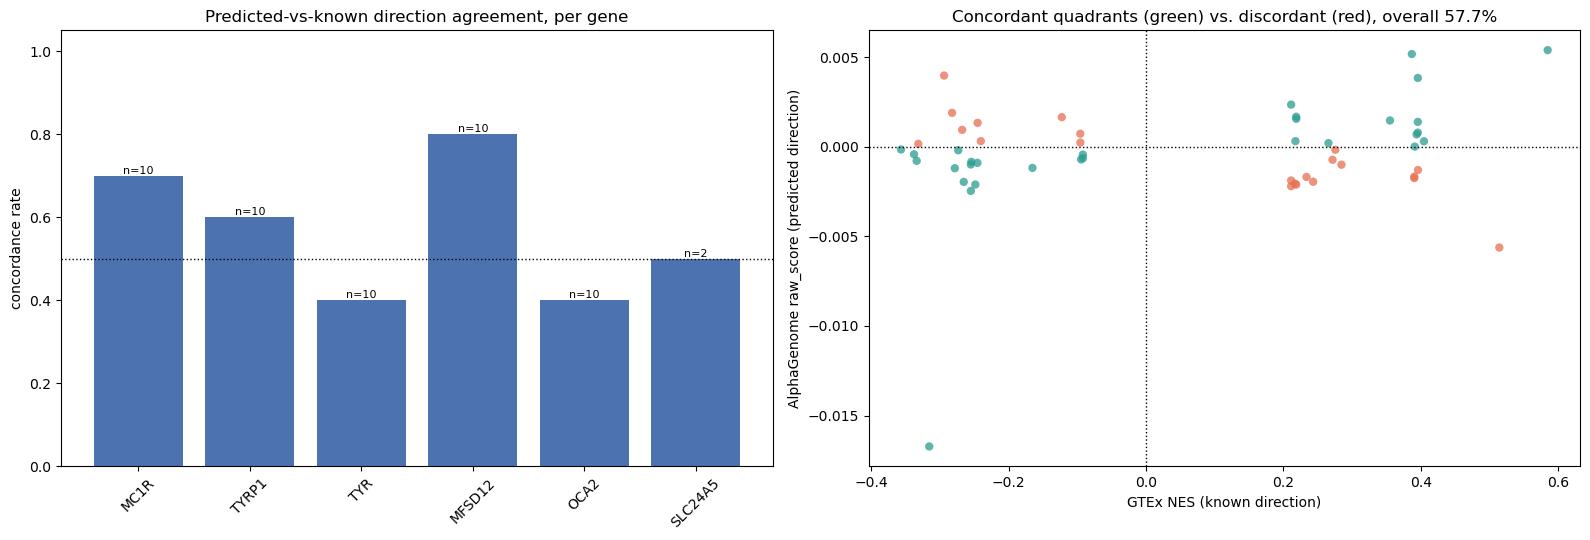

In [13]:
fig, (ax_bar, ax_scatter) = plt.subplots(1, 2, figsize=(16, 5.5))

plotted = per_gene_summary.dropna()
ax_bar.bar(plotted.index, plotted["concordance_rate"], color="#4C72B0")
for gene, row in plotted.iterrows():
    ax_bar.annotate(f"n={int(row['n_variants'])}", (gene, row["concordance_rate"]),
                     ha="center", va="bottom", fontsize=8)
ax_bar.axhline(0.5, color="black", linestyle=":", linewidth=1)
ax_bar.set_ylim(0, 1.05)
ax_bar.set_ylabel("concordance rate")
ax_bar.set_title("Predicted-vs-known direction agreement, per gene")
ax_bar.tick_params(axis="x", rotation=45)

colors = concordance_df["agree"].map({True: "#2A9D8F", False: "#E76F51"})
ax_scatter.scatter(concordance_df["nes"], concordance_df["raw_score"], c=colors, alpha=0.75, edgecolor="none")
ax_scatter.axhline(0, color="black", linestyle=":", linewidth=1)
ax_scatter.axvline(0, color="black", linestyle=":", linewidth=1)
ax_scatter.set_xlabel("GTEx NES (known direction)")
ax_scatter.set_ylabel("AlphaGenome raw_score (predicted direction)")
ax_scatter.set_title(f"Concordant quadrants (green) vs. discordant (red), overall {overall_rate:.1%}")

plt.tight_layout()
plt.show()
